h          | DoFs       | L2 Error        | H1 Error       
-----------------------------------------------------------------
0.2        | 677        | 2.26851e-03     | 5.13137e-02
0.1        | 2889       | 1.02424e-03     | 3.46089e-02
0.05       | 11981      | 5.00738e-04     | 2.42554e-02
0.025      | 48429      | 2.49466e-04     | 1.71429e-02
0.0125     | 189257     | 1.24507e-04     | 1.21191e-02

Experimental Convergence Rates:
L2 Rates: ['1.15', '1.03', '1.01', '1.00']
H1 Rates: ['0.57', '0.51', '0.50', '0.50']


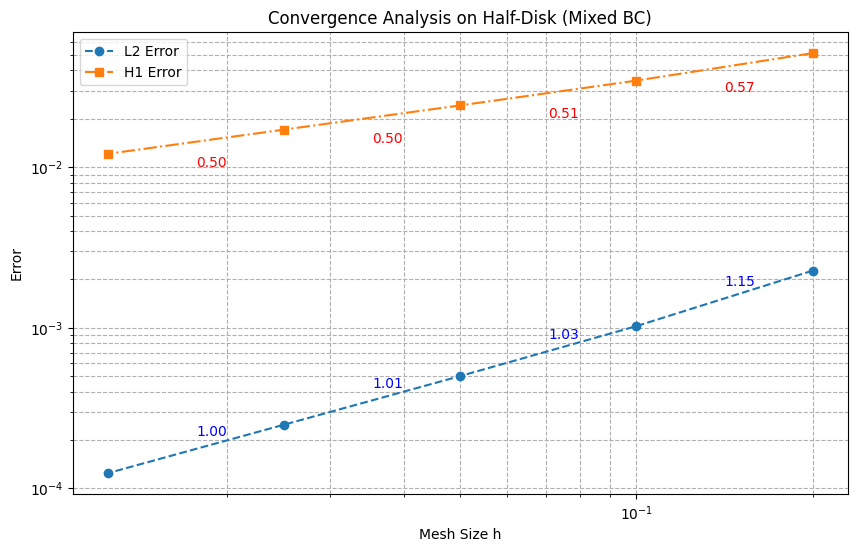

In [10]:
from ngsolve import *
from netgen.geom2d import SplineGeometry
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. DEFINE GEOMETRY (Upper Half-Disk with Splines)
# -----------------------------------------------------------------------------
def make_half_disk():
    geo = SplineGeometry()
    
    # Points
    p_origin = geo.AppendPoint(0, 0)
    p_right = geo.AppendPoint(1, 0)
    p_top = geo.AppendPoint(0, 1)
    p_left = geo.AppendPoint(-1, 0)
    
    # Control points for Rational Splines (corners of the square)
    # This creates perfect circular arcs
    p_c1 = geo.AppendPoint(1, 1)
    p_c2 = geo.AppendPoint(-1, 1)
    
    # Segments
    # 1. Positive x-axis (Dirichlet): (0,0) -> (1,0)
    geo.Append(["line", p_origin, p_right], bc="dirichlet_bottom")
    
    # 2. Right Arc (Dirichlet): (1,0) -> (0,1)
    geo.Append(["spline3", p_right, p_c1, p_top], bc="dirichlet_arc")
    
    # 3. Left Arc (Dirichlet): (0,1) -> (-1,0)
    geo.Append(["spline3", p_top, p_c2, p_left], bc="dirichlet_arc")
    
    # 4. Negative x-axis (Neumann): (-1,0) -> (0,0)
    # This is Gamma_N
    geo.Append(["line", p_left, p_origin], bc="neumann")
    
    return geo

# Define Exact Solution
# r = sqrt(x^2 + y^2), theta = atan2(y,x) (returns 0 to pi in upper half)
r = sqrt(x**2 + y**2)
theta = atan2(y, x)
u_exact = r**(0.5) * sin(0.5 * theta)

# Gradient for H1 error
grad_u_exact = CF((u_exact.Diff(x), u_exact.Diff(y)))

# -----------------------------------------------------------------------------
# 2. SOLVER FUNCTION
# -----------------------------------------------------------------------------
def solve_problem(h_size):
    geo = make_half_disk()
    mesh = Mesh(geo.GenerateMesh(maxh=h_size))
    
    # Space: H1 with Dirichlet on specific boundaries
    # We apply Dirichlet to everything EXCEPT "neumann"
    fes = H1(mesh, order=4, dirichlet="dirichlet_bottom|dirichlet_arc")
    u, v = fes.TnT()
    
    # Bilinear Form (Stiffness Matrix)
    a = BilinearForm(fes)
    a += grad(u) * grad(v) * dx
    a.Assemble()
    
    # Linear Form
    # f = 0 in domain.
    # Neumann BC is homogeneous (grad u * n = 0), so boundary integral is also 0.
    f = LinearForm(fes)
    f.Assemble()
    
    # Boundary Conditions (Homogenization)
    gfu = GridFunction(fes)
    gfu.Set(u_exact, definedon=mesh.Boundaries("dirichlet_bottom|dirichlet_arc"))
    
    # Solve
    r_vec = f.vec.CreateVector()
    r_vec.data = f.vec - a.mat * gfu.vec
    inv = a.mat.Inverse(freedofs=fes.FreeDofs())
    gfu.vec.data += inv * r_vec
    
    # Errors
    errL2 = sqrt(Integrate((gfu - u_exact)**2, mesh))
    errH1 = sqrt(Integrate((grad(gfu) - grad_u_exact)**2, mesh))
    
    return fes.ndof, errL2, errH1

# -----------------------------------------------------------------------------
# 3. CONVERGENCE STUDY
# -----------------------------------------------------------------------------
h_vals = [0.2, 0.1, 0.05, 0.025, 0.0125]
errL2 = []
errH1 = []

print(f"{'h':<10} | {'DoFs':<10} | {'L2 Error':<15} | {'H1 Error':<15}")
print("-" * 65)

for h in h_vals:
    ndof, el2, eh1 = solve_problem(h)
    errL2.append(el2)
    errH1.append(eh1)
    print(f"{h:<10} | {ndof:<10} | {el2:.5e}     | {eh1:.5e}")

# Calculate Rates
l2_rates = []
h1_rates = []
for i in range(len(h_vals)-1):
    l2_rates.append(np.log(errL2[i]/errL2[i+1]) / np.log(h_vals[i]/h_vals[i+1]))
    h1_rates.append(np.log(errH1[i]/errH1[i+1]) / np.log(h_vals[i]/h_vals[i+1]))

print("\nExperimental Convergence Rates:")
print("L2 Rates:", [f"{r:.2f}" for r in l2_rates])
print("H1 Rates:", [f"{r:.2f}" for r in h1_rates])

# -----------------------------------------------------------------------------
# 4. PLOTTING
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.loglog(h_vals, errL2, 'o--', label='L2 Error')
plt.loglog(h_vals, errH1, 's-.', label='H1 Error')

# Add rate annotations
for i, rate in enumerate(l2_rates):
    plt.text(np.sqrt(h_vals[i]*h_vals[i+1]), np.sqrt(errL2[i]*errL2[i+1])*1.2, f"{rate:.2f}", color='blue')
for i, rate in enumerate(h1_rates):
    plt.text(np.sqrt(h_vals[i]*h_vals[i+1]), np.sqrt(errH1[i]*errH1[i+1])*0.7, f"{rate:.2f}", color='red')

plt.xlabel('Mesh Size h')
plt.ylabel('Error')
plt.title('Convergence Analysis on Half-Disk (Mixed BC)')
plt.legend()
plt.grid(True, which="both", linestyle="--")
plt.show()